# Using a CatBoost model for each group

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm
import catboost as cb

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GroupKFold



### Read files & submission file for template

In [2]:
X_train = pd.read_csv('../data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('../data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('../data/y_train.csv',index_col='ROW_ID')
y_train_clf = pd.DataFrame((y_train['target']>0).astype(int))
sample_submission = pd.read_csv('../submissions/sample_submission.csv',index_col='ROW_ID')

In [3]:
X_train.head(5)

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


In [4]:
print("Details in the GROUP feature:")
print(X_train['GROUP'].value_counts())

Details in the GROUP feature:
GROUP
3    168913
2    134928
4    123062
1    100170
Name: count, dtype: int64


### Features

In [5]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [6]:
X_train.fillna(0)
X_test.fillna(0)

for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    X_train[ f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    X_train[ f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    X_test[ f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(1)
    X_test[ f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')

"""
# Hash ALLOCATION values
hash_allocation = {v: i for i, v in enumerate(X_train['ALLOCATION'].value_counts().index)}
X_train['ALLOCATION'] = X_train['ALLOCATION'].map(hash_allocation).fillna(-1).astype(int)
X_test['ALLOCATION'] = X_test['ALLOCATION'].map(hash_allocation).fillna(-1).astype(int)
"""
# Split datasets by GROUP
group_values = sorted(X_train['GROUP'].dropna().unique())
X_train_by_group = {g: X_train[X_train['GROUP'] == g].copy() for g in group_values}
y_train_by_group = {g: y_train_clf.loc[X_train_by_group[g].index].copy() for g in group_values}
X_test_by_group = {g: X_test[X_test['GROUP'] == g].copy() for g in group_values}

print(f"Created {len(group_values)} group-specific datasets.")
for g in group_values:
    print(
        f"GROUP {g}: train={X_train_by_group[g].shape[0]}, "
        f"test={X_test_by_group[g].shape[0]}"
    )

Created 4 group-specific datasets.
GROUP 1: train=100170, test=7980
GROUP 2: train=134928, test=8050
GROUP 3: train=168913, test=7980
GROUP 4: train=123062, test=7860


In [15]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features # + ['ALLOCATION']
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'STD_PERF_{i}' for i in [20]]
features = features + [ f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]

print("Features used for the model:")
print(features)

Features used for the model:
['RET_1', 'RET_2', 'RET_3', 'RET_4', 'RET_5', 'RET_6', 'RET_7', 'RET_8', 'RET_9', 'RET_10', 'RET_11', 'RET_12', 'RET_13', 'RET_14', 'RET_15', 'RET_16', 'RET_17', 'RET_18', 'RET_19', 'RET_20', 'SIGNED_VOLUME_1', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_20', 'MEDIAN_DAILY_TURNOVER', 'AVERAGE_PERF_3', 'AVERAGE_PERF_5', 'AVERAGE_PERF_10', 'AVERAGE_PERF_15', 'AVERAGE_PERF_20', 'ALLOCATIONS_AVERAGE_PERF_3', 'ALLOCATIONS_AVERAGE_PERF_5', 'ALLOCATIONS_AVERAGE_PERF_10', 'ALLOCATIONS_AVERAGE_PERF_15', 'ALLOCATIONS_AVERAGE_PERF_20', 'STD_PERF_20', 'ALLOCATIONS_STD_PERF_20']


### Fitting a catboost using cross validation

In [16]:
features_lgbm = features

In [31]:
scores_cb = []
models_cb = []
models_cb_by_group = {}
scores_cb_by_group = {}

for group_value in sorted(X_train['GROUP'].dropna().unique()):
    X_group = X_train[X_train['GROUP'] == group_value]
    y_group = y_train_clf.loc[X_group.index, 'target']

    train_dates = X_group['TS'].unique()
    if len(train_dates) < 2:
        print(f"Skipping GROUP {group_value}: not enough unique TS values for CV")
        continue

    n_splits_group = min(8, len(train_dates))
    if n_splits_group < 2:
        print(f"Skipping GROUP {group_value}: n_splits < 2")
        continue

    print(f"\n=== GROUP {group_value} | n_splits={n_splits_group} ===")

    group_models = []
    group_scores = []

    splits = KFold(n_splits=n_splits_group).split(train_dates)

    for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
        local_train_dates = train_dates[local_train_dates_ids]
        local_test_dates = train_dates[local_test_dates_ids]

        local_train_ids = X_group['TS'].isin(local_train_dates)
        local_test_ids = X_group['TS'].isin(local_test_dates)

        X_local_train = X_group.loc[local_train_ids, [x for x in features_lgbm]]
        y_local_train = y_group.loc[local_train_ids]

        X_local_test = X_group.loc[local_test_ids, [x for x in features_lgbm]]
        y_local_test = y_group.loc[local_test_ids]

        train_data = cb.Pool(
            X_local_train,
            label=y_local_train,
        )
        valid_data = cb.Pool(
            X_local_test,
            label=y_local_test,
        )

        model_cb = cb.CatBoostClassifier(
            n_estimators=200,
            depth=4,
            learning_rate=1e-1,
            random_seed=42,
            thread_count=50,
            verbose=True
        )

        model_cb.fit(train_data, eval_set=valid_data, early_stopping_rounds=50, use_best_model=True)
        y_local_pred = model_cb.predict(X_local_test).astype(int).ravel()

        group_models.append(model_cb)
        models_cb.append(model_cb)

        score = accuracy_score((y_local_test > 0).astype(int), (y_local_pred > 0).astype(int))
        group_scores.append(score)
        scores_cb.append(score)
        print(f"GROUP {group_value} - Fold {i+1} - Accuracy: {score * 100:.2f}%")

    models_cb_by_group[group_value] = group_models
    scores_cb_by_group[group_value] = group_scores

    mean_g = np.mean(group_scores) * 100
    std_g = np.std(group_scores) * 100
    print(f"GROUP {group_value} Accuracy: {mean_g:.2f}% [{mean_g - std_g:.2f} ; {mean_g + std_g:.2f}] (+- {std_g:.2f})")

mean = np.mean(scores_cb) * 100
std = np.std(scores_cb) * 100

u = mean + std
l = mean - std

print(f'\nGlobal Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')


=== GROUP 1 | n_splits=8 ===
0:	learn: 0.6924174	test: 0.6928051	best: 0.6928051 (0)	total: 24.5ms	remaining: 4.88s
1:	learn: 0.6917548	test: 0.6932197	best: 0.6928051 (0)	total: 41.4ms	remaining: 4.1s
2:	learn: 0.6911805	test: 0.6933645	best: 0.6928051 (0)	total: 54ms	remaining: 3.55s
3:	learn: 0.6906440	test: 0.6934303	best: 0.6928051 (0)	total: 69.7ms	remaining: 3.41s
4:	learn: 0.6901581	test: 0.6933448	best: 0.6928051 (0)	total: 88.3ms	remaining: 3.44s
5:	learn: 0.6897544	test: 0.6934548	best: 0.6928051 (0)	total: 103ms	remaining: 3.33s
6:	learn: 0.6894112	test: 0.6935473	best: 0.6928051 (0)	total: 127ms	remaining: 3.5s
7:	learn: 0.6890001	test: 0.6933500	best: 0.6928051 (0)	total: 149ms	remaining: 3.57s
8:	learn: 0.6885701	test: 0.6932782	best: 0.6928051 (0)	total: 164ms	remaining: 3.47s
9:	learn: 0.6882582	test: 0.6933729	best: 0.6928051 (0)	total: 201ms	remaining: 3.82s
10:	learn: 0.6879520	test: 0.6932549	best: 0.6928051 (0)	total: 244ms	remaining: 4.19s
11:	learn: 0.6875440	t

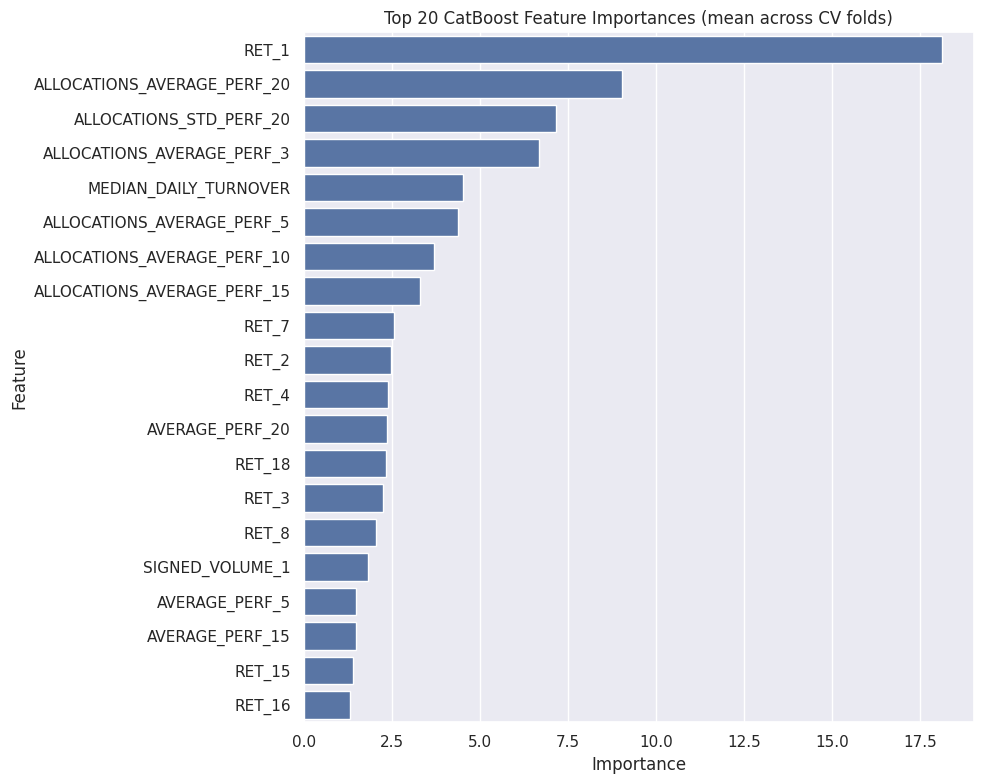

In [33]:
feature_importances = pd.DataFrame(
	[model_cb.get_feature_importance(type='FeatureImportance') for model_cb in models_cb],
	columns=features_lgbm
)

top_features = feature_importances.mean(0).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, orient='h')
plt.title('Top 20 CatBoost Feature Importances (mean across CV folds)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

### Taking the most sure model

In [19]:
preds_list = []
for model_cb in models_cb:
    preds = model_cb.predict_proba(X_test[features_lgbm])[:, 1]
    preds_list.append(preds)
preds_array = np.array(preds_list)

preds_final = np.take_along_axis(
    preds_array,
    np.argmax(np.abs(preds_array - 0.5), axis=0)[None, :],
    axis=0
).ravel()
pd.DataFrame(preds_final>0.5, index=X_test.index, columns=['target']).to_csv('../submissions/cat_boost_submission.csv')

### Produce a solution blending the catboost models (weight by probability)

In [20]:
preds = np.zeros(X_test.shape[0])
for model_cb in models_cb:
    preds += model_cb.predict_proba(X_test[features_lgbm])[:,1]

preds /= len(models_cb)
preds = pd.DataFrame(preds,
                    index=sample_submission.index,
                    columns=['target']
)
preds.head()

,target
ROW_ID,
527073,0.492387
527074,0.509782
527075,0.494928
527076,0.484751
527077,0.486208


In [21]:
(preds>0.5).astype(int).to_csv('../submissions/preds_catboost.csv')
print("Predictions saved to ../submissions/preds_catboost.csv")

Predictions saved to ../submissions/preds_catboost.csv


### Retrain a solution on the full training data and predict on the test set.

In [32]:
models_cb_full_by_group = {}
preds_cb_series = pd.Series(index=X_test.index, dtype=float)

train_groups = sorted(X_train['GROUP'].dropna().unique())

for g in train_groups:
    train_mask = X_train['GROUP'] == g
    test_mask = X_test['GROUP'] == g

    if train_mask.sum() == 0:
        continue

    train_data_g = cb.Pool(
        X_train.loc[train_mask, features_lgbm],
        label=y_train_clf.loc[train_mask, 'target'],
    )

    model_g = cb.CatBoostClassifier(
        n_estimators=150,
        depth=4,
        learning_rate=1e-1,
        random_seed=42,
        thread_count=-1,
        verbose=True
    )

    model_g.fit(train_data_g)
    models_cb_full_by_group[g] = model_g

    if test_mask.sum() > 0:
        preds_cb_series.loc[test_mask] = model_g.predict_proba(
            X_test.loc[test_mask, features_lgbm]
        )[:, 1]

    print(f"GROUP {g}: train={train_mask.sum()}, test={test_mask.sum()}")

# Fallback for unseen/missing groups in test
missing_mask = preds_cb_series.isna()
if missing_mask.any():
    print(f"Unseen GROUP rows in test: {missing_mask.sum()} -> fallback to global model")
    train_data_full = cb.Pool(
        X_train[features_lgbm],
        label=y_train_clf['target'],
    )
    model_cb_fallback = cb.CatBoostClassifier(
        n_estimators=30,
        depth=4,
        random_seed=42,
        thread_count=-1,
        verbose=True
    )
    model_cb_fallback.fit(train_data_full,)
    preds_cb_series.loc[missing_mask] = model_cb_fallback.predict_proba(
        X_test.loc[missing_mask, features_lgbm]
    )[:, 1]

preds_cb = pd.DataFrame(
    preds_cb_series,
    index=sample_submission.index,
    columns=['target']
)

preds_cb.head()

0:	learn: 0.6925437	total: 12.5ms	remaining: 1.87s
1:	learn: 0.6920577	total: 25.3ms	remaining: 1.87s
2:	learn: 0.6914244	total: 38.4ms	remaining: 1.88s
3:	learn: 0.6909523	total: 50.8ms	remaining: 1.85s
4:	learn: 0.6905767	total: 64.5ms	remaining: 1.87s
5:	learn: 0.6901750	total: 75.1ms	remaining: 1.8s
6:	learn: 0.6898066	total: 86.7ms	remaining: 1.77s
7:	learn: 0.6894752	total: 99.9ms	remaining: 1.77s
8:	learn: 0.6891061	total: 113ms	remaining: 1.77s
9:	learn: 0.6889047	total: 124ms	remaining: 1.74s
10:	learn: 0.6884598	total: 136ms	remaining: 1.72s
11:	learn: 0.6881633	total: 149ms	remaining: 1.72s
12:	learn: 0.6878956	total: 162ms	remaining: 1.71s
13:	learn: 0.6875289	total: 174ms	remaining: 1.69s
14:	learn: 0.6872873	total: 187ms	remaining: 1.68s
15:	learn: 0.6870278	total: 199ms	remaining: 1.67s
16:	learn: 0.6868396	total: 214ms	remaining: 1.67s
17:	learn: 0.6866311	total: 227ms	remaining: 1.66s
18:	learn: 0.6864025	total: 240ms	remaining: 1.66s
19:	learn: 0.6860730	total: 255ms	

,target
ROW_ID,
527073,0.472121
527074,0.521991
527075,0.483009
527076,0.517272
527077,0.473112


In [34]:
(preds_cb > 0.5).astype(int).to_csv('../submissions/preds_catboost_groups.csv')
print("Predictions saved to ../submissions/preds_catboost_groups.csv")

Predictions saved to ../submissions/preds_catboost_groups.csv
